### Libraries

In [1]:
import logging
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from investment_lab.data.option_db import OptionLoader, extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.rates import compute_forward

from investment_lab.surface.reference_iv import (
    SVIReferenceIVExtractor,
    SSVIReferenceIVExtractor,
)

from investment_lab.stochastic.heston_ssm import HestonStateSpaceModel

from investment_lab.signals.implied_realized_spread import build_implied_realized_spread
from investment_lab.signals.allocation import build_zscore_allocation_signal, build_percentile_allocation_signal

from investment_lab.option_trade import VarianceSwap
from investment_lab.backtest import BacktesterBidAskFromData
from investment_lab.strategies.dynamic_allocation import DynamicAllocationOverlay

from investment_lab.metrics.performance import evaluate_backtest 
from investment_lab.signals.naive_spread import build_naive_implied_realized_spread

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)

### Inputs

In [ ]:
TICKER = "SPY"

START_DATE = datetime(2020, 1, 2)
END_DATE = datetime(2022, 12, 30)

TARGET_DTE = 30
TARGET_MONEYNESS = 1.0

ROLLING_WINDOW = 126 
FORECAST_HORIZON_DAYS = 30

USE_SURFACE_MODEL = "SSVI"   

ZSCORE_ROLLING_WINDOW = 60
HIGH_THRESHOLD = 0.6
LOW_THRESHOLD = 0.4
MIN_ALLOCATION = -0.3
MAX_ALLOCATION = 1.0
ZSCORE_SCALING = 0.25
ZSCORE_CENTER = 0.5

### Load data

In [4]:
df_options = OptionLoader.load_data(
    start_date=START_DATE,
    end_date=END_DATE,
    process_kwargs={"ticker": TICKER},
)

df_options = df_options.sort_values(["date", "expiration", "strike"]).reset_index(drop=True)
df_options.head()

2026-04-07 17:22:07,050 - INFO - Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-04-07 17:22:57,132 - INFO - Processing with {'ticker': 'SPY'}
2026-04-07 17:22:57,247 - INFO - Potentially add extra field with None


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness
0,324.87,260.0,2020-01-03,1.00000,0.00000,0.00000,-0.00041,0.01423,0.00000,64.56,64.76,1.0,C,SPY 20200103C260,64.66,SPY,2020-01-02,1,0.800320
1,324.87,260.0,2020-01-03,-0.00049,0.00016,0.00057,-0.00476,0.00000,0.96296,0.00,0.00,0.0,P,SPY 20200103P260,0.00,SPY,2020-01-02,1,0.800320
2,324.87,265.0,2020-01-03,1.00000,0.00000,0.00000,0.00000,0.01476,0.00000,59.49,59.73,0.0,C,SPY 20200103C265,59.61,SPY,2020-01-02,1,0.815711
3,324.87,265.0,2020-01-03,-0.00086,0.00017,0.00097,-0.00515,-0.00023,0.88540,0.00,0.02,1.0,P,SPY 20200103P265,0.01,SPY,2020-01-02,1,0.815711
4,324.87,270.0,2020-01-03,1.00000,0.00000,0.00000,0.00000,0.01467,0.00000,54.50,54.70,0.0,C,SPY 20200103C270,54.60,SPY,2020-01-02,1,0.831102


In [5]:
df_rates = USRatesLoader.load_data(
    start_date=max(START_DATE, datetime(2020, 1, 2)),
    end_date=END_DATE,
)

df_options = compute_forward(df_options=df_options, df_rates=df_rates)
df_options.head()

2026-04-07 17:23:28,826 - INFO - Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-04-07 17:23:29,668 - INFO - Processing with None
2026-04-07 17:23:29,670 - INFO - Potentially add extra field with None
C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\rates.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_compute_values)


,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,...,volume,call_put,option_id,mid,ticker,date,day_to_expiration,moneyness,risk_free_rate,forward
0,324.87,260.0,2020-01-03,1.00000,0.00000,0.00000,-0.00041,0.01423,0.00000,64.56,...,1.0,C,SPY 20200103C260,64.660,SPY,2020-01-02,1,0.800320,0.015300,324.883609
1,324.87,293.0,2020-09-30,-0.24350,0.00628,0.87615,-0.03130,-0.64979,0.17822,7.77,...,1.0,P,SPY 20200930P293,7.825,SPY,2020-01-02,272,0.901899,0.015651,328.678601
2,324.87,293.0,2020-09-30,0.73435,0.00583,0.90409,-0.02956,1.15850,0.21085,40.01,...,5.0,C,SPY 20200930C293,40.110,SPY,2020-01-02,272,0.901899,0.015651,328.678601
3,324.87,292.0,2020-09-30,-0.23629,0.00617,0.86177,-0.03042,-0.62930,0.17746,7.21,...,476.0,P,SPY 20200930P292,7.480,SPY,2020-01-02,272,0.898821,0.015651,328.678601
4,324.87,292.0,2020-09-30,0.74014,0.00577,0.89429,-0.02866,1.15671,0.21294,40.81,...,0.0,C,SPY 20200930C292,40.925,SPY,2020-01-02,272,0.898821,0.015651,328.678601


In [6]:
df_spot = extract_spot_from_options(df_options).copy()
df_spot["ticker"] = TICKER
df_spot = df_spot.sort_values("date").reset_index(drop=True)
df_spot["log_spot"] = np.log(df_spot["spot"])
df_spot["log_return"] = df_spot["log_spot"].diff()
df_spot.head()

,date,spot,ticker,log_spot,log_return
0,2020-01-02,324.87,SPY,5.783425,NaN
1,2020-01-03,322.43,SPY,5.775886,-0.007539
2,2020-01-06,323.68,SPY,5.779755,0.003869
3,2020-01-07,322.74,SPY,5.776847,-0.002908
4,2020-01-08,324.39,SPY,5.781946,0.005099


### Implied vol

In [7]:
if USE_SURFACE_MODEL.upper() == "SVI":
    iv_extractor = SVIReferenceIVExtractor(
        target_day_to_expiration=TARGET_DTE,
        target_moneyness=TARGET_MONEYNESS,
        minimum_points_per_expiry=5,
    )
elif USE_SURFACE_MODEL.upper() == "SSVI":
    iv_extractor = SSVIReferenceIVExtractor(
        target_day_to_expiration=TARGET_DTE,
        target_moneyness=TARGET_MONEYNESS,
        minimum_points_per_expiry=5,
    )
else:
    raise ValueError("USE_SURFACE_MODEL must be 'SVI' or 'SSVI'.")

df_iv_reference = iv_extractor.extract(df_options)
df_iv_reference.head()

2026-04-07 17:26:06,248 - INFO - Extracting reference IV on 7178158 option rows.


2026-04-07 17:26:16,548 - INFO - After filtering: 6630716 rows remaining.
2026-04-07 17:26:18,401 - INFO - Fitting SSVI model on 156 records
2026-04-07 17:26:18,440 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-07 17:26:18,455 - INFO - Fitting SSVI model on 77 records
2026-04-07 17:26:18,457 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-07 17:26:18,459 - INFO - Fitting SSVI model on 81 records
2026-04-07 17:26:18,466 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-07 17:26:18,470 - INFO - Fitting SSVI model on 127 records
2026-04-07 17:26:18,472 - INFO - Successfully fitted SSVI. Parameters: [ 0.2 -0.3  0.5  0.2]
2026-04-07 17:26:18,474 - INFO - Fitting SSVI model on 100 records
2026-04-07 17:26:18,481 - INFO - Successfully fitted SSVI. Parameters: [ 0.19998797 -0.3000001   0.50000008  0.20000028]
2026-04-07 17:26:18,485 - INFO - Fitting SSVI model on 105 records
2026-04-07 17:26:18,489 - INFO - 

,date,ticker,iv_reference,target_day_to_expiration,target_moneyness,n_fitted_expiries
0,2020-01-02,SPY,0.184890,30,1.0,37
1,2020-01-03,SPY,0.175630,30,1.0,37
2,2020-01-06,SPY,0.135746,30,1.0,36
3,2020-01-07,SPY,0.155383,30,1.0,37
4,2020-01-08,SPY,0.162833,30,1.0,36


### Heston state space model

In [8]:
heston_ssm = HestonStateSpaceModel(
    rolling_window=ROLLING_WINDOW,
    forecast_horizon_days=FORECAST_HORIZON_DAYS,
    measurement_error=1e-6,
    variance_proxy_error=0.01,
    rv_proxy_window=15,
)

df_heston = heston_ssm.rolling_fit_predict(
    df_spot[["date", "spot"]],
    recalibration_frequency=5,   
)
df_heston["ticker"] = TICKER

2026-04-07 17:48:04,678 - INFO - Diffusion params (moments): xi=0.744, rho=-0.025, mu=0.034 | Initial kappa=5.00, theta=0.0679 (vol=26.1%)


2026-04-07 17:48:20,639 - INFO - Hybrid calibrated: kappa=2.719, theta=0.1958 (vol=44.3%) | fixed xi=0.744, rho=-0.025 | NLL=-294.65
2026-04-07 17:48:20,646 - INFO - Diffusion params (moments): xi=0.738, rho=-0.024, mu=0.059 | Initial kappa=5.00, theta=0.0679 (vol=26.1%)
2026-04-07 17:48:31,931 - INFO - Hybrid calibrated: kappa=0.711, theta=0.5664 (vol=75.3%) | fixed xi=0.738, rho=-0.024 | NLL=-293.51
2026-04-07 17:48:31,935 - INFO - Diffusion params (moments): xi=0.737, rho=-0.023, mu=0.058 | Initial kappa=5.00, theta=0.0679 (vol=26.1%)
2026-04-07 17:48:41,788 - INFO - Hybrid calibrated: kappa=5.000, theta=0.0543 (vol=23.3%) | fixed xi=0.737, rho=-0.023 | NLL=-292.90
2026-04-07 17:48:41,794 - INFO - Diffusion params (moments): xi=0.738, rho=-0.024, mu=0.066 | Initial kappa=5.00, theta=0.0679 (vol=26.1%)
2026-04-07 17:49:11,416 - INFO - Hybrid calibrated: kappa=4.457, theta=0.0612 (vol=24.7%) | fixed xi=0.738, rho=-0.024 | NLL=-296.49
2026-04-07 17:49:11,420 - INFO - Diffusion params (

In [9]:
print("=== Paramètres calibrés ===")
print(df_heston[["kappa", "theta", "xi", "rho"]].describe())
print()
print("=== Forecast vs proxies ===")
print(f"Forecast vol  : {df_heston['forecast_volatility'].describe()}")
print(f"Filtered var  : {df_heston['filtered_variance'].describe()}")
if "rv_proxy" in df_heston.columns:
    print(f"RV proxy      : {df_heston['rv_proxy'].describe()}")
print()
print(f"sqrt(theta) moyen = {np.sqrt(df_heston['theta'].mean()):.4f}")
print(f"sqrt(filtered_var) moyen = {np.sqrt(df_heston['filtered_variance'].mean()):.4f}")

=== Paramètres calibrés ===
            kappa       theta          xi         rho
count  633.000000  633.000000  633.000000  633.000000
mean     4.915189    0.014407    0.177343   -0.095152
std      0.454347    0.053514    0.170217    0.085422
min      0.710725    0.005000    0.100000   -0.330199
25%      5.000000    0.005000    0.105081   -0.143291
50%      5.000000    0.005000    0.121406   -0.071809
75%      5.000000    0.005000    0.152803   -0.010000
max      5.000000    0.566410    0.791382   -0.010000

=== Forecast vs proxies ===
Forecast vol  : count    633.000000
mean       0.146936
std        0.042678
min        0.083151
25%        0.111000
50%        0.149507
75%        0.176884
max        0.314557
Name: forecast_volatility, dtype: float64
Filtered var  : count    633.000000
mean       0.023409
std        0.013875
min        0.006914
25%        0.012321
50%        0.022352
75%        0.031288
max        0.098946
Name: filtered_variance, dtype: float64
RV proxy      : count  

### Implied Realized spread

In [10]:
df_spread = build_implied_realized_spread(
    df_iv_reference=df_iv_reference,
    df_heston_forecast=df_heston,
)

df_spread = df_spread.sort_values(["ticker", "date"]).reset_index(drop=True)
df_spread.head()

,date,ticker,iv_reference,forecast_volatility,filtered_variance,spread
0,2020-07-02,SPY,0.233392,0.314557,0.098946,-0.081165
1,2020-07-06,SPY,0.226652,0.305005,0.093028,-0.078352
2,2020-07-07,SPY,0.233017,0.297182,0.088317,-0.064164
3,2020-07-08,SPY,0.379648,0.289492,0.083805,0.090156
4,2020-07-09,SPY,0.233940,0.281992,0.079519,-0.048052


In [11]:
df_spread_naive = build_naive_implied_realized_spread(
    df_iv_reference=df_iv_reference,
    df_spot=df_spot,
    rolling_window=FORECAST_HORIZON_DAYS, 
)
FIRST_TRADE_DATE = pd.to_datetime(df_spread["date"].min()).to_pydatetime()
df_spread_naive = df_spread_naive.sort_values(["ticker", "date"]).loc[df_spread_naive["date"] >= FIRST_TRADE_DATE,:].reset_index(drop=True)
df_spread_naive.head()

,date,ticker,iv_reference,rolling_realized_vol,spread
0,2020-07-02,SPY,0.233392,0.259893,-0.026501
1,2020-07-06,SPY,0.226652,0.259440,-0.032787
2,2020-07-07,SPY,0.233017,0.260561,-0.027544
3,2020-07-08,SPY,0.379648,0.261063,0.118585
4,2020-07-09,SPY,0.233940,0.260025,-0.026086


### Build allocations

In [12]:
df_allocation = build_zscore_allocation_signal(
    df_spread=df_spread,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
    zscore_scaling=ZSCORE_SCALING,
    center_at=ZSCORE_CENTER,
)

df_allocation = df_allocation.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation.head()

,date,ticker,spread,spread_zscore,allocation
0,2020-09-25,SPY,0.061728,0.930787,0.732697
1,2020-09-28,SPY,0.072857,1.051595,0.762899
2,2020-09-29,SPY,0.066685,0.933160,0.733290
3,2020-09-30,SPY,-0.034133,-0.497207,0.375698
4,2020-10-01,SPY,0.016306,0.237838,0.559459


In [13]:
df_allocation_naive = build_zscore_allocation_signal(
    df_spread=df_spread_naive,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
    zscore_scaling=ZSCORE_SCALING,
    center_at=ZSCORE_CENTER,
)
df_allocation_naive = df_allocation_naive.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation_naive.head()

,date,ticker,spread,spread_zscore,allocation
0,2020-09-25,SPY,0.026791,0.244463,0.561116
1,2020-09-28,SPY,0.023033,0.187657,0.546914
2,2020-09-29,SPY,0.017156,0.104312,0.526078
3,2020-09-30,SPY,-0.085870,-1.158087,0.210478
4,2020-10-01,SPY,-0.037174,-0.531505,0.367124


In [14]:
df_allocation_percentile = build_percentile_allocation_signal(
    df_spread=df_spread,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    high_threshold=HIGH_THRESHOLD,
    low_threshold=LOW_THRESHOLD,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
)
df_allocation_percentile = df_allocation_percentile.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation_percentile.head()

,date,ticker,spread,spread_percentile,allocation
0,2020-07-02,SPY,-0.081165,NaN,0.0
1,2020-07-06,SPY,-0.078352,NaN,0.0
2,2020-07-07,SPY,-0.064164,NaN,0.0
3,2020-07-08,SPY,0.090156,NaN,0.0
4,2020-07-09,SPY,-0.048052,NaN,0.0


In [15]:
df_allocation_percentile_naive = build_percentile_allocation_signal(
    df_spread=df_spread_naive,
    spread_col="spread",
    rolling_window=ZSCORE_ROLLING_WINDOW,
    high_threshold=HIGH_THRESHOLD,
    low_threshold=LOW_THRESHOLD,
    min_allocation=MIN_ALLOCATION,
    max_allocation=MAX_ALLOCATION,
)
df_allocation_percentile_naive = df_allocation_percentile_naive.dropna(subset=["allocation"]).reset_index(drop=True)
df_allocation_percentile_naive.head()

,date,ticker,spread,spread_percentile,allocation
0,2020-07-02,SPY,-0.026501,NaN,0.0
1,2020-07-06,SPY,-0.032787,NaN,0.0
2,2020-07-07,SPY,-0.027544,NaN,0.0
3,2020-07-08,SPY,0.118585,NaN,0.0
4,2020-07-09,SPY,-0.026086,NaN,0.0


### Plot spreads

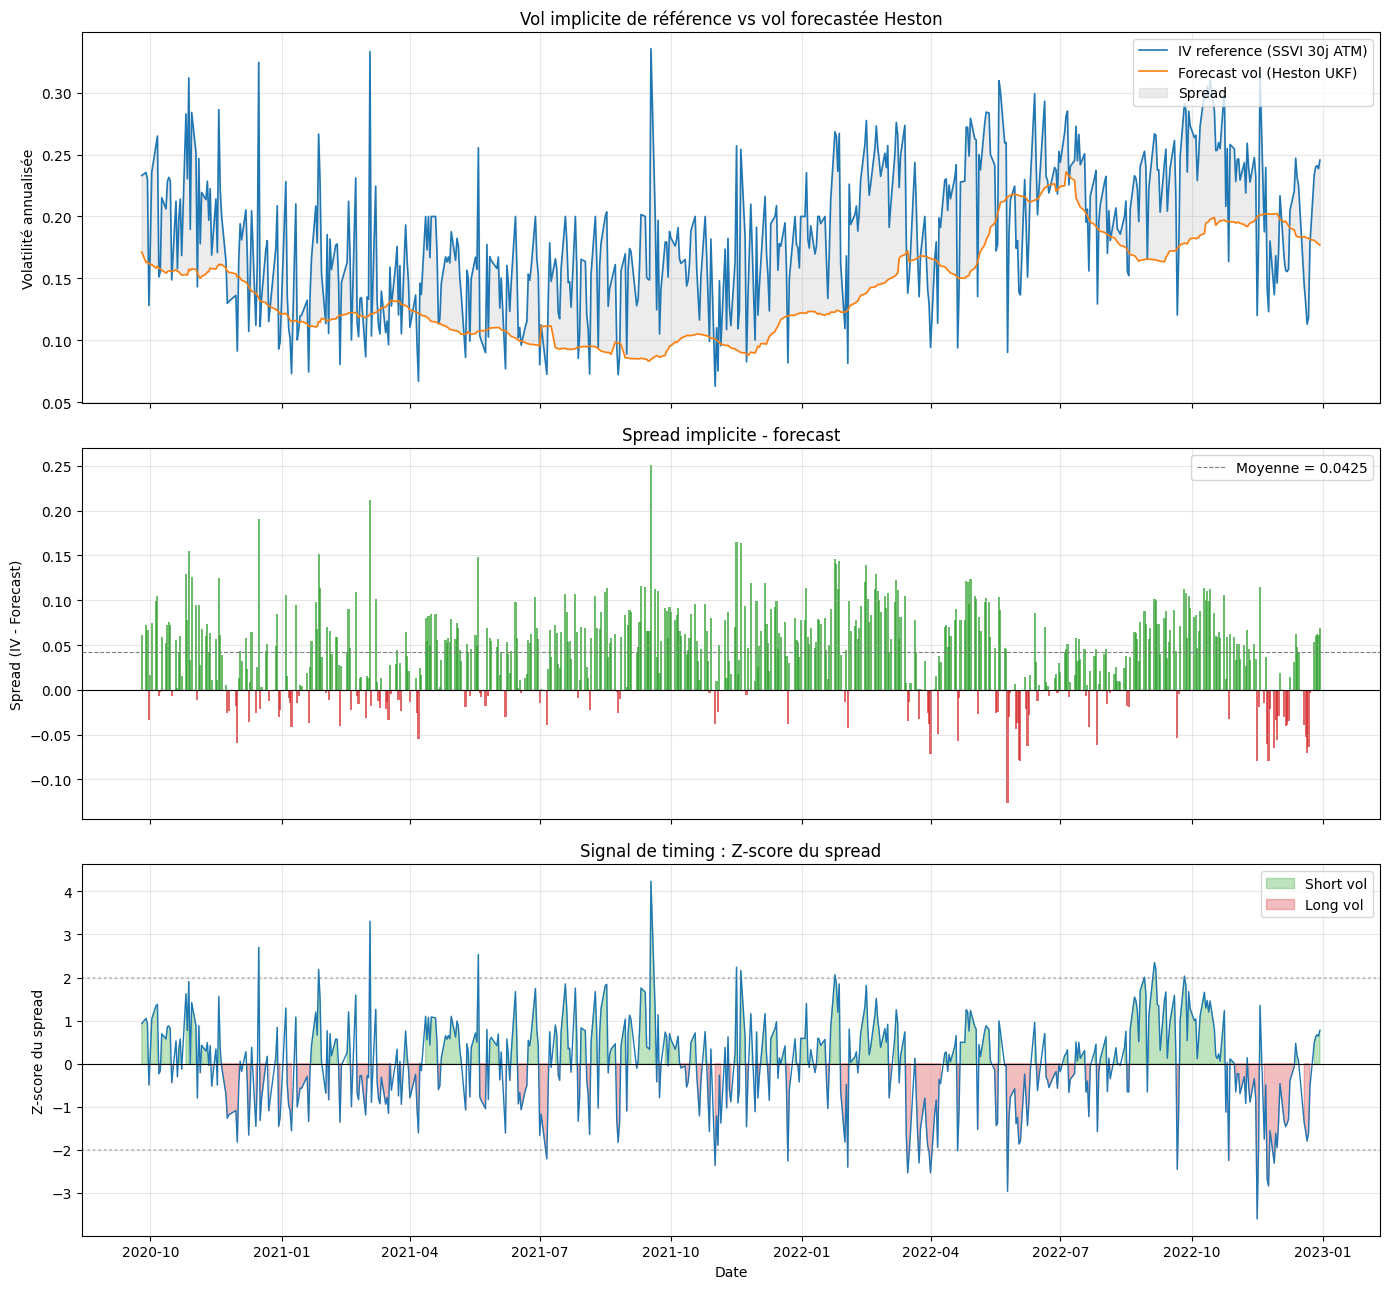

In [16]:
df_signal_plot = (
    df_spread.merge(
        df_allocation[["date", "ticker", "allocation", "spread_zscore"]],
        on=["date", "ticker"],
        how="inner",
    )
    .sort_values("date")
)

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

# IV vs Heston vol forecast
ax1 = axes[0]
ax1.plot(df_signal_plot["date"], df_signal_plot["iv_reference"], label="IV reference (SSVI 30j ATM)", linewidth=1.2)
ax1.plot(df_signal_plot["date"], df_signal_plot["forecast_volatility"], label="Forecast vol (Heston UKF)", linewidth=1.2)
ax1.fill_between(
    df_signal_plot["date"],
    df_signal_plot["iv_reference"],
    df_signal_plot["forecast_volatility"],
    alpha=0.15,
    color="gray",
    label="Spread",
)
ax1.set_ylabel("Volatilité annualisée")
ax1.legend(loc="upper right")
ax1.set_title("Vol implicite de référence vs vol forecastée Heston")
ax1.grid(alpha=0.3)

# Spread
ax2 = axes[1]
spread = df_signal_plot["spread"]
colors = ["tab:green" if s >= 0 else "tab:red" for s in spread]
ax2.bar(df_signal_plot["date"], spread, color=colors, width=1.5, alpha=0.7)
ax2.axhline(0.0, color="black", linewidth=0.8)
ax2.axhline(spread.mean(), color="gray", linestyle="--", linewidth=0.8, label=f"Moyenne = {spread.mean():.4f}")
ax2.set_ylabel("Spread (IV - Forecast)")
ax2.legend(loc="upper right")
ax2.set_title("Spread implicite - forecast")
ax2.grid(alpha=0.3)

# Z-score
ax3 = axes[2]
zscore = df_signal_plot["spread_zscore"]
ax3.plot(df_signal_plot["date"], zscore, color="tab:blue", linewidth=1.0)
ax3.fill_between(df_signal_plot["date"], zscore, 0, where=(zscore > 0), alpha=0.3, color="tab:green", label="Short vol")
ax3.fill_between(df_signal_plot["date"], zscore, 0, where=(zscore < 0), alpha=0.3, color="tab:red", label="Long vol")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.axhline(2, color="gray", linestyle=":", alpha=0.5)
ax3.axhline(-2, color="gray", linestyle=":", alpha=0.5)
ax3.set_ylabel("Z-score du spread")
ax3.set_xlabel("Date")
ax3.legend(loc="upper right")
ax3.set_title("Signal de timing : Z-score du spread")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Generate strategies

In [17]:
VARIANCE_SWAP_LEG = [
    {
        "day_to_expiry_target": TARGET_DTE,
        "strike_spacing": 5,
        "weight": -1,
        "rebal_week_day": [0, 1, 2, 3, 4],  
    }
]

In [18]:
df_allocation["date"] = pd.to_datetime(df_allocation["date"])

In [19]:
# Generate var swap trades
df_trades_varswap = VarianceSwap.generate_trades(
    start_date=FIRST_TRADE_DATE,
    end_date=END_DATE,
    tickers=TICKER,
    legs=VARIANCE_SWAP_LEG,
)

# Var swap static
bt_static = BacktesterBidAskFromData(df_trades_varswap).compute_backtest()

# Var swap dynamic heston
df_trades_heston = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_heston = BacktesterBidAskFromData(df_trades_heston).compute_backtest()

# Var swap dynamic naive
df_trades_naive = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation_naive,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_naive = BacktesterBidAskFromData(df_trades_naive).compute_backtest()


# Var swap dynamic heston
df_trades_percentile_heston = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation_percentile,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_percentile_heston = BacktesterBidAskFromData(df_trades_percentile_heston).compute_backtest()

# Var swap dynamic naive
df_trades_percentile_naive = DynamicAllocationOverlay.apply_to_trades(
    df_trades=df_trades_varswap,
    df_allocation=df_allocation_percentile_naive,
    lag_business_days=1,
    allocation_col="allocation",
    fill_value=0.0,
)
bt_percentile_naive = BacktesterBidAskFromData(df_trades_percentile_naive).compute_backtest()

2026-04-07 18:26:50,071 - INFO - Loading option data from 2020-07-02 00:00:00 to 2022-12-30 00:00:00
2026-04-07 18:26:50,074 - INFO - Reading between 2020-07-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-04-07 18:27:26,066 - INFO - Processing with {'ticker': 'SPY'}
2026-04-07 18:27:26,134 - INFO - Potentially add extra field with None
2026-04-07 18:27:46,771 - INFO - Preprocessing option data.
2026-04-07 18:27:46,816 - INFO - Selecting options for leg: VARIANCE SWAP using the rules:
{'day_to_expiry_target': 30}


         spot  strike expiration    delta    gamma     vega    theta      rho  \
0      312.22   313.0 2020-07-31  0.49700  0.02035  0.35710 -0.13163  0.12140   
1      312.22   314.0 2020-07-31  0.47603  0.02069  0.35586 -0.12865  0.11601   
2      312.22   315.0 2020-07-31  0.45418  0.02091  0.35471 -0.12637  0.11165   
3      312.22   316.0 2020-07-31  0.43205  0.02102  0.35128 -0.12316  0.10568   
4      312.22   317.0 2020-07-31  0.40964  0.02119  0.34784 -0.11962  0.10082   
...       ...     ...        ...      ...      ...      ...      ...      ...   
96653  382.44   378.0 2023-01-27 -0.39167  0.01715  0.41172 -0.13622 -0.11482   
96654  382.44   379.0 2023-01-27 -0.40848  0.01740  0.41658 -0.13637 -0.11963   
96655  382.44   380.0 2023-01-27 -0.42535  0.01765  0.41957 -0.13709 -0.12364   
96656  382.44   381.0 2023-01-27 -0.44301  0.01794  0.42342 -0.13650 -0.12851   
96657  382.44   382.0 2023-01-27 -0.46118  0.01820  0.42505 -0.13523 -0.13284   

       implied_volatility  

C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\option_trade.py:310: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df_group: cls._normalize_strike_weights(df_group, target_weight=weight))
2026-04-07 18:27:50,231 - INFO - Converting 96658 df_trades to daily time series
2026-04-07 18:28:41,192 - INFO - Forward filling option data for df
C:\Users\33761\OneDrive - CentraleSupelec\Documents\Cours 4A\Stratégie de la volatilité\Code\Dauphine-Lecture-Volatility\investment_lab\util.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future versio

In [20]:
results = pd.DataFrame([
    evaluate_backtest(bt_static.nav, "var_swap_static"),
    evaluate_backtest(bt_heston.nav, "var_swap_dynamic_heston", df_allocation),
    evaluate_backtest(bt_naive.nav, "var_swap_dynamic_naive", df_allocation_naive),
    evaluate_backtest(bt_percentile_heston.nav, "var_swap_dynamic_heston_percentile", df_allocation_percentile),
    evaluate_backtest(bt_percentile_naive.nav, "var_swap_dynamic_naive_percentile", df_allocation_percentile_naive),
])

results

,strategy,annual_return,annual_vol,max_drawdown,sharpe,calmar,hit_ratio,avg_turnover
0,var_swap_static,0.087792,0.113089,-0.106579,0.776310,0.823729,0.604294,NaN
1,var_swap_dynamic_heston,0.038619,0.067143,-0.079448,0.575174,0.486090,0.535276,0.202139
2,var_swap_dynamic_naive,0.041389,0.053257,-0.064494,0.777152,0.641750,0.538344,0.187229
3,var_swap_dynamic_heston_percentile,0.017436,0.049149,-0.057403,0.354749,0.303739,0.412577,0.264306
4,var_swap_dynamic_naive_percentile,0.029021,0.031209,-0.027017,0.929900,1.074160,0.400307,0.233716


### Plot results

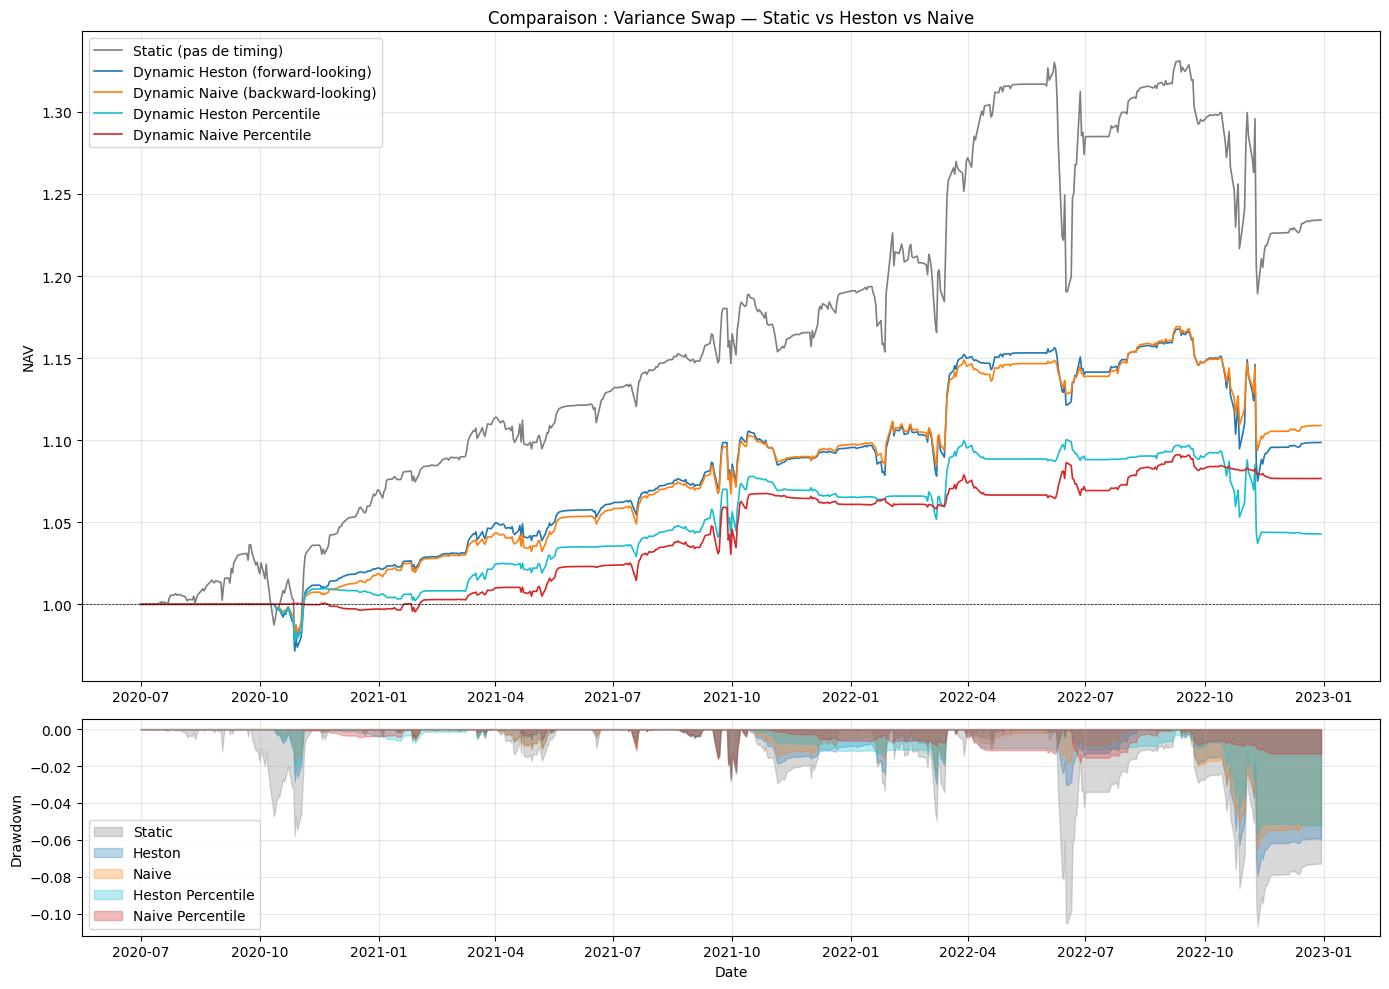

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

# NAV
ax1 = axes[0]
for name, bt, color in [
    ("Static (pas de timing)", bt_static, "tab:gray"),
    ("Dynamic Heston (forward-looking)", bt_heston, "tab:blue"),
    ("Dynamic Naive (backward-looking)", bt_naive, "tab:orange"),
    ("Dynamic Heston Percentile", bt_percentile_heston, "tab:cyan"),
    ("Dynamic Naive Percentile", bt_percentile_naive, "tab:red"),
]:
    nav = bt.nav["NAV"]
    ax1.plot(nav.index, nav.values, label=name, color=color, linewidth=1.2)

ax1.axhline(1.0, color="black", linewidth=0.5, linestyle="--")
ax1.set_ylabel("NAV")
ax1.set_title("Comparaison : Variance Swap — Static vs Heston vs Naive")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3)

# Drawdown
ax2 = axes[1]
for name, bt, color in [
    ("Static", bt_static, "tab:gray"),
    ("Heston", bt_heston, "tab:blue"),
    ("Naive", bt_naive, "tab:orange"),
    ("Heston Percentile", bt_percentile_heston, "tab:cyan"),
    ("Naive Percentile", bt_percentile_naive, "tab:red"),
]:
    nav = bt.nav["NAV"]
    dd = (nav / nav.cummax()) - 1
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.3, color=color, label=name)

ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.legend(loc="lower left")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()



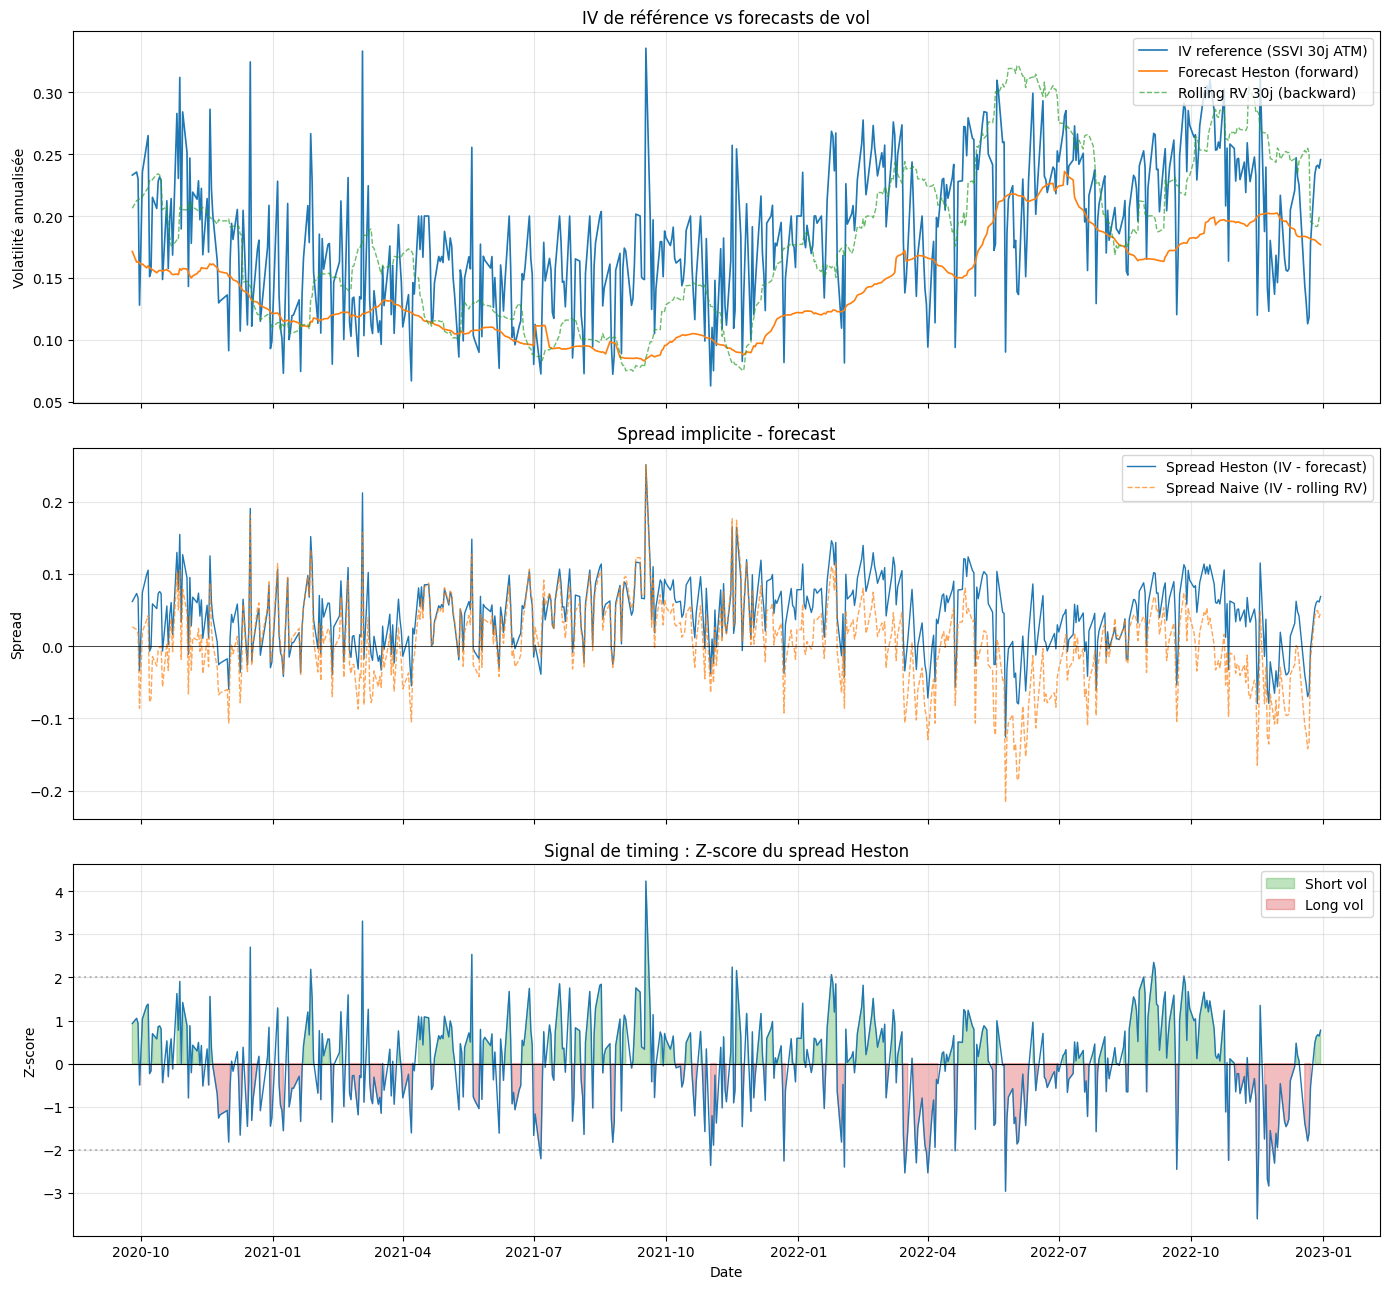

In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

df_plot = (
    df_spread
    .merge(
        df_allocation[["date", "ticker", "allocation", "spread_zscore"]],
        on=["date", "ticker"], how="inner",
    )
    .sort_values("date")
)

# IV vs Heston vs Naive realized vol
ax1 = axes[0]
ax1.plot(df_plot["date"], df_plot["iv_reference"], label="IV reference (SSVI 30j ATM)", linewidth=1.2)
ax1.plot(df_plot["date"], df_plot["forecast_volatility"], label="Forecast Heston (forward)", linewidth=1.2)

# Realized vol naive
df_naive_plot = df_spread_naive[["date", "ticker", "rolling_realized_vol"]].copy()
df_plot_merged = df_plot.merge(df_naive_plot, on=["date", "ticker"], how="left")
ax1.plot(df_plot_merged["date"], df_plot_merged["rolling_realized_vol"],
         label="Rolling RV 30j (backward)", linewidth=1.0, linestyle="--", alpha=0.7)

ax1.set_ylabel("Volatilité annualisée")
ax1.legend(loc="upper right")
ax1.set_title("IV de référence vs forecasts de vol")
ax1.grid(alpha=0.3)

# Spread Heston vs Spread naive
ax2 = axes[1]
ax2.plot(df_plot["date"], df_plot["spread"], label="Spread Heston (IV - forecast)", linewidth=1.0)

df_naive_spread_plot = df_spread_naive[["date", "ticker", "spread"]].rename(columns={"spread": "spread_naive"})
df_plot_merged2 = df_plot.merge(df_naive_spread_plot, on=["date", "ticker"], how="left")
ax2.plot(df_plot_merged2["date"], df_plot_merged2["spread_naive"],
         label="Spread Naive (IV - rolling RV)", linewidth=1.0, linestyle="--", alpha=0.7)

ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_ylabel("Spread")
ax2.legend(loc="upper right")
ax2.set_title("Spread implicite - forecast")
ax2.grid(alpha=0.3)

# Z-score Heston
ax3 = axes[2]
zscore = df_plot["spread_zscore"]
ax3.plot(df_plot["date"], zscore, color="tab:blue", linewidth=1.0)
ax3.fill_between(df_plot["date"], zscore, 0, where=(zscore > 0),
                 alpha=0.3, color="tab:green", label="Short vol")
ax3.fill_between(df_plot["date"], zscore, 0, where=(zscore < 0),
                 alpha=0.3, color="tab:red", label="Long vol")
ax3.axhline(0, color="black", linewidth=0.8)
ax3.axhline(2, color="gray", linestyle=":", alpha=0.5)
ax3.axhline(-2, color="gray", linestyle=":", alpha=0.5)
ax3.set_ylabel("Z-score")
ax3.set_xlabel("Date")
ax3.legend(loc="upper right")
ax3.set_title("Signal de timing : Z-score du spread Heston")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1400x1000 with 2 Axes>